# Testing ligand features

We want to add some quick n easy to calculate rdkit features to our dataset to allow forward feature selection.

In [95]:
from rdkit import Chem
from rdkit import RDLogger
from rdkit.Chem import Descriptors
import pandas as pd
import os
import sys
import helper_functions as h

dataset_name='SAMPL'
print(f'Using dataset {dataset_name}')

#SAMPL has some molecules that cannot be featurised :(
Failures = [] #

save_dir=r'C:\Users\eg16993\OneDrive - University of Bristol\Documents\Datasets\topol_datasets'
data_dir=r'C:\Users\eg16993\OneDrive - University of Bristol\Documents\Datasets'
results_dir=r"C:\Users\eg16993\OneDrive - University of Bristol\Documents\Results\graphs_and_topology\d_" + dataset_name

test_file=dataset_name + '.csv'
output_file = dataset_name + 'rdkit.csv'

og_dataset=pd.read_csv(os.path.join(data_dir,test_file))
og_dataset

def gets_smiles_from_og_datasets(dataset_name):
    """
    Gives the name and SMILEs column heading for each dataset
    """
    smiles_column_name_in_orig_dataset={}
    smiles_column_name_in_orig_dataset['SAMPL']='smiles'

    names_column_name_in_orig_dataset={}
    names_column_name_in_orig_dataset['SAMPL']='iupac'
    
    return names_column_name_in_orig_dataset[dataset_name], smiles_column_name_in_orig_dataset[dataset_name]



def rdkit_from_smiles_list(smiles_list, names_list=[], number_to_run=''):
    """
    Does rdkit featurising from a smiles_list, returns dataframe of features and 
    a list of failures
    inputs:
    smiles_list: list of smiles strings
    names_list: names for each molecule (will use numbers if not given)
    number_to_run, set to a number to run the first 'x' instead of all of them
    """
    # feature dict for later dataframe
    features = {}
    # descriptors come from rdkit
    descriptors = {d[0]: d[1] for d in Descriptors.descList}
    # failure array for non-rdkit featurisable molecules
    failures=[]
    # now we loop over and create molecules (with hydrogens)
    if number_to_run == '':
        # do all
        number_to_run = len(smiles_list)
    # loop over all smiles and featurise
    for mol_num in range(number_to_run):
        # mol is rdkit molcule object, coords in atoms in space
        mol, coords = h.coord_creator(smiles_list[mol_num])
        if len(names_list) == 0:
            # use number indexing as empty list
            this_molecule_name = mol_num
        else:
            this_molecule_name = names_list[mol_num]
        if mol_num % 100 == 0:
            print(f'Got to molecule {mol_num}: {this_molecule_name}: {smiles_list[mol_num]}')
            print(f'Failures so far: {failures}')
        try:
            # does the rdkit featurising
            features[this_molecule_name] = {d: descriptors[d](mol) for d in descriptors}

        except ValueError as e:
            print(e)
            failures.append([mol_num, this_molecule_name])
            continue
            
    features = pd.DataFrame.from_dict(features).T
    
    return features, failures

def make_rdkit_dataset(dataset_name, 
                       output_file='',
                       save_dir='',
                       column_heading_name=[], 
                       column_heading_smiles=[]):
    """
    Reads the SMILEs column from a csv file and creates a rdkit dataset
    
    """
    if output_file == '':
        output_file= dataset_name + 'rdkit.csv'
    # get column headings
    if column_heading_smiles == []:
        # assume the heading is in the function
        column_heading_name, column_heading_smiles = gets_smiles_from_og_datasets(dataset_name)
    else:
        if column_heading_name == []:
            column_heading_name = [x for x in range(column_heading_smiles)]
    # make a list of SMILEs and names
    names_list=og_dataset[column_heading_name]
    print(f'First five names are:\n{names_list[:5]}')
    smiles_list=og_dataset[column_heading_smiles]
    print(f'First five SMILES are:\n{smiles_list[:5]}')
    

    # and featurise with whatever rdkit offers
    features, failures = rdkit_from_smiles_list(smiles_list, names_list)
    # write it to a file
    features.to_csv(os.path.join(save_dir,output_file))
    
    return features, failures

features, failures = make_rdkit_dataset(dataset_name)

Using dataset SAMPL
First five names are:
0    4-methoxy-N,N-dimethyl-benzamide
1            methanesulfonyl chloride
2                   3-methylbut-1-ene
3                     2-ethylpyrazine
4                         heptan-1-ol
Name: iupac, dtype: object
First five SMILES are:
0    CN(C)C(=O)c1ccc(cc1)OC
1              CS(=O)(=O)Cl
2                  CC(C)C=C
3                CCc1cnccn1
4                  CCCCCCCO
Name: smiles, dtype: object
Got to molecule 0: 4-methoxy-N,N-dimethyl-benzamide: CN(C)C(=O)c1ccc(cc1)OC
Failures so far: []
Got to molecule 100: 1-chloropropane: CCCCl
Failures so far: []
Got to molecule 200: cyclopentanone: C1CCC(=O)C1
Failures so far: []
Got to molecule 300: 4-propylphenol: CCCc1ccc(cc1)O
Failures so far: []
Got to molecule 400: 1,2,4-trimethylbenzene: Cc1ccc(c(c1)C)C
Failures so far: []
Got to molecule 500: pentachloronitrobenzene: c1(c(c(c(c(c1Cl)Cl)Cl)Cl)Cl)N(=O)=O
Failures so far: []
Got to molecule 600: isobutyl acetate: CC(C)COC(=O)C
Failures so f

In [92]:
features, failures = rdkit_from_smiles_list(smiles_list, names_list, number_to_run=5)

Got to molecule 0: 4-methoxy-N,N-dimethyl-benzamide: CN(C)C(=O)c1ccc(cc1)OC
Failures so far: []


In [93]:
features

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
"4-methoxy-N,N-dimethyl-benzamide",12.428170,-3.458874,12.428170,0.519264,0.686360,179.219,166.115,179.094629,70.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
methanesulfonyl chloride,9.855710,-4.368056,9.855710,3.074846,0.421427,114.553,111.529,113.954228,32.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3-methylbut-1-ene,7.349537,-3.289005,7.349537,1.280324,0.412737,70.135,60.055,70.078250,30.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2-ethylpyrazine,7.363796,-3.006484,7.363796,0.587878,0.536795,108.144,100.080,108.068748,42.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
heptan-1-ol,7.581250,-4.173333,7.581250,3.423878,0.544191,116.204,100.076,116.120115,50.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [94]:
features, failures = make_rdkit_dataset(dataset_name)

#features.to_csv(os.path.join(save_dir,output_file))

First five names are:
0    4-methoxy-N,N-dimethyl-benzamide
1            methanesulfonyl chloride
2                   3-methylbut-1-ene
3                     2-ethylpyrazine
4                         heptan-1-ol
Name: iupac, dtype: object
First five SMILES are:
0    CN(C)C(=O)c1ccc(cc1)OC
1              CS(=O)(=O)Cl
2                  CC(C)C=C
3                CCc1cnccn1
4                  CCCCCCCO
Name: smiles, dtype: object
Got to molecule 0: 4-methoxy-N,N-dimethyl-benzamide: CN(C)C(=O)c1ccc(cc1)OC
Failures so far: []
Got to molecule 100: 1-chloropropane: CCCCl
Failures so far: []
Got to molecule 200: cyclopentanone: C1CCC(=O)C1
Failures so far: []
Got to molecule 300: 4-propylphenol: CCCc1ccc(cc1)O
Failures so far: []
Got to molecule 400: 1,2,4-trimethylbenzene: Cc1ccc(c(c1)C)C
Failures so far: []
Got to molecule 500: pentachloronitrobenzene: c1(c(c(c(c(c1Cl)Cl)Cl)Cl)Cl)N(=O)=O
Failures so far: []
Got to molecule 600: isobutyl acetate: CC(C)COC(=O)C
Failures so far: []


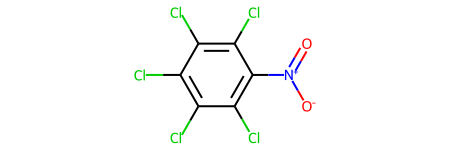

In [96]:
test_SMILES = 'c1(c(c(c(c(c1Cl)Cl)Cl)Cl)Cl)N(=O)=O'
Chem.MolFromSmiles(test_SMILES)

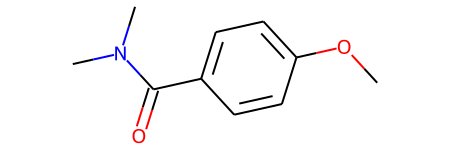

In [32]:
mol = Chem.MolFromSmiles(test_SMILES)
mol

In [33]:
mol.GetNumAtoms()

13

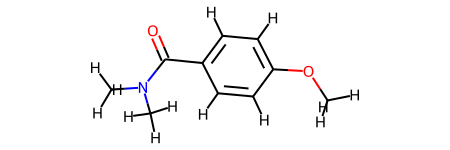

In [35]:
mol, coords = h.coord_creator(test_SMILES)
mol

In [36]:
mol.GetNumAtoms()

26

In [37]:
coords = mol.GetConformer().GetPositions()

In [38]:
mol.GetNumAtoms()

26

In [39]:
# load ligands and compute features
features = {}
descriptors = {d[0]: d[1] for d in Descriptors.descList}
descriptors

{'MaxEStateIndex': <function rdkit.Chem.EState.EState.MaxEStateIndex(mol, force=1)>,
 'MinEStateIndex': <function rdkit.Chem.EState.EState.MinEStateIndex(mol, force=1)>,
 'MaxAbsEStateIndex': <function rdkit.Chem.EState.EState.MaxAbsEStateIndex(mol, force=1)>,
 'MinAbsEStateIndex': <function rdkit.Chem.EState.EState.MinAbsEStateIndex(mol, force=1)>,
 'qed': <function rdkit.Chem.QED.qed(mol, w=QEDproperties(MW=0.66, ALOGP=0.46, HBA=0.05, HBD=0.61, PSA=0.06, ROTB=0.65, AROM=0.48, ALERTS=0.95), qedProperties=None)>,
 'MolWt': <function rdkit.Chem.Descriptors.<lambda>(*x, **y)>,
 'HeavyAtomMolWt': <function rdkit.Chem.Descriptors.HeavyAtomMolWt(x)>,
 'ExactMolWt': <function rdkit.Chem.Descriptors.<lambda>(*x, **y)>,
 'NumValenceElectrons': <function rdkit.Chem.Descriptors.NumValenceElectrons(mol)>,
 'NumRadicalElectrons': <function rdkit.Chem.Descriptors.NumRadicalElectrons(mol)>,
 'MaxPartialCharge': <function rdkit.Chem.Descriptors.MaxPartialCharge(mol, force=False)>,
 'MinPartialCharge'

In [40]:
failures=[]
for mol_num in range(5):
    mol, coords = h.coord_creator(smiles_list[mol_num])
    try:
        features[mol_num] = {d: descriptors[d](mol) for d in descriptors}
    except ValueError as e:
        print(e)
        failures.append(mol_num)
        continue

In [41]:
features

{0: {'MaxEStateIndex': 12.42817046957672,
  'MinEStateIndex': -3.4588736536281184,
  'MaxAbsEStateIndex': 12.42817046957672,
  'MinAbsEStateIndex': 0.5192638652683303,
  'qed': 0.6863601614688654,
  'MolWt': 179.21900000000008,
  'HeavyAtomMolWt': 166.11499999999995,
  'ExactMolWt': 179.094628656,
  'NumValenceElectrons': 70,
  'NumRadicalElectrons': 0,
  'MaxPartialCharge': 0.2528363683996425,
  'MinPartialCharge': -0.49676776984412796,
  'MaxAbsPartialCharge': 0.49676776984412796,
  'MinAbsPartialCharge': 0.2528363683996425,
  'FpDensityMorgan1': 1.3846153846153846,
  'FpDensityMorgan2': 2.076923076923077,
  'FpDensityMorgan3': 2.6153846153846154,
  'BCUT2D_MWHI': 2.818326535137579e-15,
  'BCUT2D_MWLOW': -0.24613807586928635,
  'BCUT2D_CHGHI': -4.4244387251437957e-17,
  'BCUT2D_CHGLO': -2.464561445258747,
  'BCUT2D_LOGPHI': 1.7803522514085073e-18,
  'BCUT2D_LOGPLOW': -2.578523184598219,
  'BCUT2D_MRHI': 9.735271071054272e-16,
  'BCUT2D_MRLOW': -0.9962631936545514,
  'BalabanJ': 3.675

In [42]:
features = pd.DataFrame.from_dict(features).T
features.to_csv(os.path.join(save_dir,output_file))

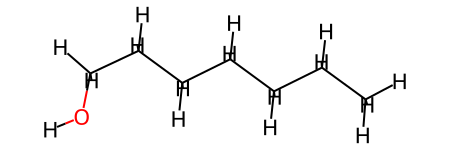

In [43]:
mol

In [44]:
features

,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,NumRadicalElectrons,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,12.428170,-3.458874,12.428170,0.519264,0.686360,179.219,166.115,179.094629,70.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,9.855710,-4.368056,9.855710,3.074846,0.421427,114.553,111.529,113.954228,32.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7.349537,-3.289005,7.349537,1.280324,0.412737,70.135,60.055,70.078250,30.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7.363796,-3.006484,7.363796,0.587878,0.536795,108.144,100.080,108.068748,42.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7.581250,-4.173333,7.581250,3.423878,0.544191,116.204,100.076,116.120115,50.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
